In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel('recorded_covid_data.xlsx')
data.head()


,Age range,Sex,Marital Status,Highest Education Level Attained,Has COVID-19 vaccine arrived your country,Have you accepted vaccination for COVID-19,Do you think the COVID-19 vaccine is safe,Do you think the COVID-19 vaccine is efficacious,Do you think the COVID-19 vaccine will alter your DNA,Do you think the COVID-19 vaccine contains a tracking device,...,Do you think one can still get COVID-19 after vaccination,Have you done COVID-19 test before,Have you been diagnosed with COVID-19 before,Should I still get the COVID-19 vaccine if I recovered from COVID,"If the government makes the COVID-19 vaccine available to the public, would you get vaccinated",Are you willing to pay for the vaccine,Do you think enough awareness has been created about the COVID-19 vaccine,COVID-19 Test Result,BMI interpretation,Depression status
0,1,0,2,0,1,1,2,0,1,1,...,0,0,0,2,3,0,0,0,0,1
1,1,1,1,3,2,1,1,2,1,1,...,2,0,0,2,0,0,0,0,0,1
2,2,1,1,3,2,1,2,2,1,1,...,0,0,0,0,2,0,0,0,0,1
3,0,0,2,0,2,1,2,2,1,1,...,2,0,0,2,5,0,1,0,0,1
4,2,1,1,3,2,1,1,2,1,1,...,1,1,0,2,0,0,0,0,0,1


In [3]:
data.isnull().sum()

Age range                                                                                         0
Sex                                                                                               0
Marital Status                                                                                    0
Highest Education Level Attained                                                                  0
Has COVID-19 vaccine arrived your country                                                         0
Have you accepted vaccination for COVID-19                                                        0
Do you think the COVID-19 vaccine is safe                                                         0
Do you think the COVID-19 vaccine is efficacious                                                  0
Do you think the COVID-19 vaccine will alter your DNA                                             0
Do you think the COVID-19 vaccine contains a tracking device                                      0


In [4]:
data.duplicated().sum()


np.int64(0)

In [5]:
data.drop_duplicates(inplace=True)

In [6]:
data.duplicated().sum()
data.head()

,Age range,Sex,Marital Status,Highest Education Level Attained,Has COVID-19 vaccine arrived your country,Have you accepted vaccination for COVID-19,Do you think the COVID-19 vaccine is safe,Do you think the COVID-19 vaccine is efficacious,Do you think the COVID-19 vaccine will alter your DNA,Do you think the COVID-19 vaccine contains a tracking device,...,Do you think one can still get COVID-19 after vaccination,Have you done COVID-19 test before,Have you been diagnosed with COVID-19 before,Should I still get the COVID-19 vaccine if I recovered from COVID,"If the government makes the COVID-19 vaccine available to the public, would you get vaccinated",Are you willing to pay for the vaccine,Do you think enough awareness has been created about the COVID-19 vaccine,COVID-19 Test Result,BMI interpretation,Depression status
0,1,0,2,0,1,1,2,0,1,1,...,0,0,0,2,3,0,0,0,0,1
1,1,1,1,3,2,1,1,2,1,1,...,2,0,0,2,0,0,0,0,0,1
2,2,1,1,3,2,1,2,2,1,1,...,0,0,0,0,2,0,0,0,0,1
3,0,0,2,0,2,1,2,2,1,1,...,2,0,0,2,5,0,1,0,0,1
4,2,1,1,3,2,1,1,2,1,1,...,1,1,0,2,0,0,0,0,0,1


<Axes: xlabel='Depression status'>

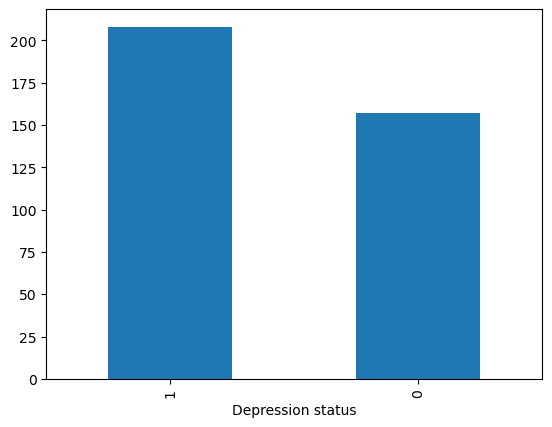

In [7]:
data["Depression status"].value_counts().plot(kind="bar")

<Axes: xlabel='BMI interpretation'>

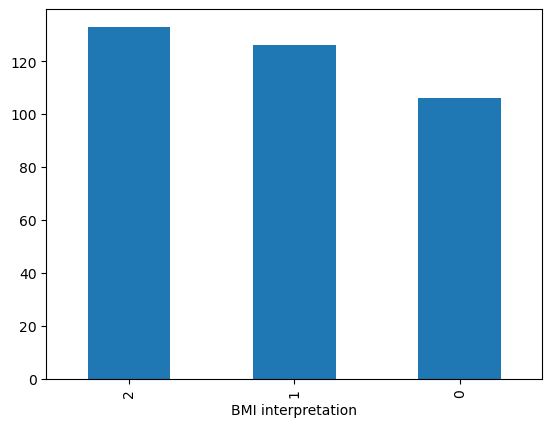

In [8]:
data["BMI interpretation"].value_counts().plot(kind="bar")

In [9]:
x = data.drop(columns=['Depression status'])
y = data['Depression status']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

print("x_train shape: {}".format(x_train.shape))
print("x_test shape: {}".format(x_test.shape))

print("y_train shape: {}".format(y_train.shape))
print("y_test shape: {}".format(y_test.shape))

x_train shape: (255, 21)
x_test shape: (110, 21)
y_train shape: (255,)
y_test shape: (110,)


In [10]:
knn = KNeighborsClassifier(n_neighbors=7)
# train the model 
knn.fit(x_train, y_train)
# predict the outcome using test data
knn_predictions = knn.predict(x_test)

# evaluate the model by comparing the predicted outcome with the test outcome
Evaluation_results = accuracy_score(y_test, knn_predictions)

print("Accuracy=")
print(Evaluation_results)

Accuracy=
0.5727272727272728


In [11]:
knn_result = permutation_importance(knn, x, y, n_repeats=10)
importance_knn = knn_result.importances_mean

importance_knn = pd.DataFrame({'Feature': x.columns, 'Importance': importance_knn})

# Sort by importance and visualize (optional)
importance_knn = importance_knn.sort_values(by='Importance', ascending=False)
print(importance_knn.head(10).to_markdown(index=False, numalign="left", stralign="left"))

| Feature                                                                                        | Importance   |
|:-----------------------------------------------------------------------------------------------|:-------------|
| Highest Education Level Attained                                                               | 0.0282192    |
| If the government makes the COVID-19 vaccine available to the public, would you get vaccinated | 0.0191781    |
| COVID-19 Test Result                                                                           | 0.00986301   |
| Has COVID-19 vaccine arrived your country                                                      | 0.00219178   |
| Have you done COVID-19 test before                                                             | -0.000547945 |
| Have you been diagnosed with COVID-19 before                                                   | -0.00219178  |
| Do you think enough awareness has been created about the COVID-19 vaccine             

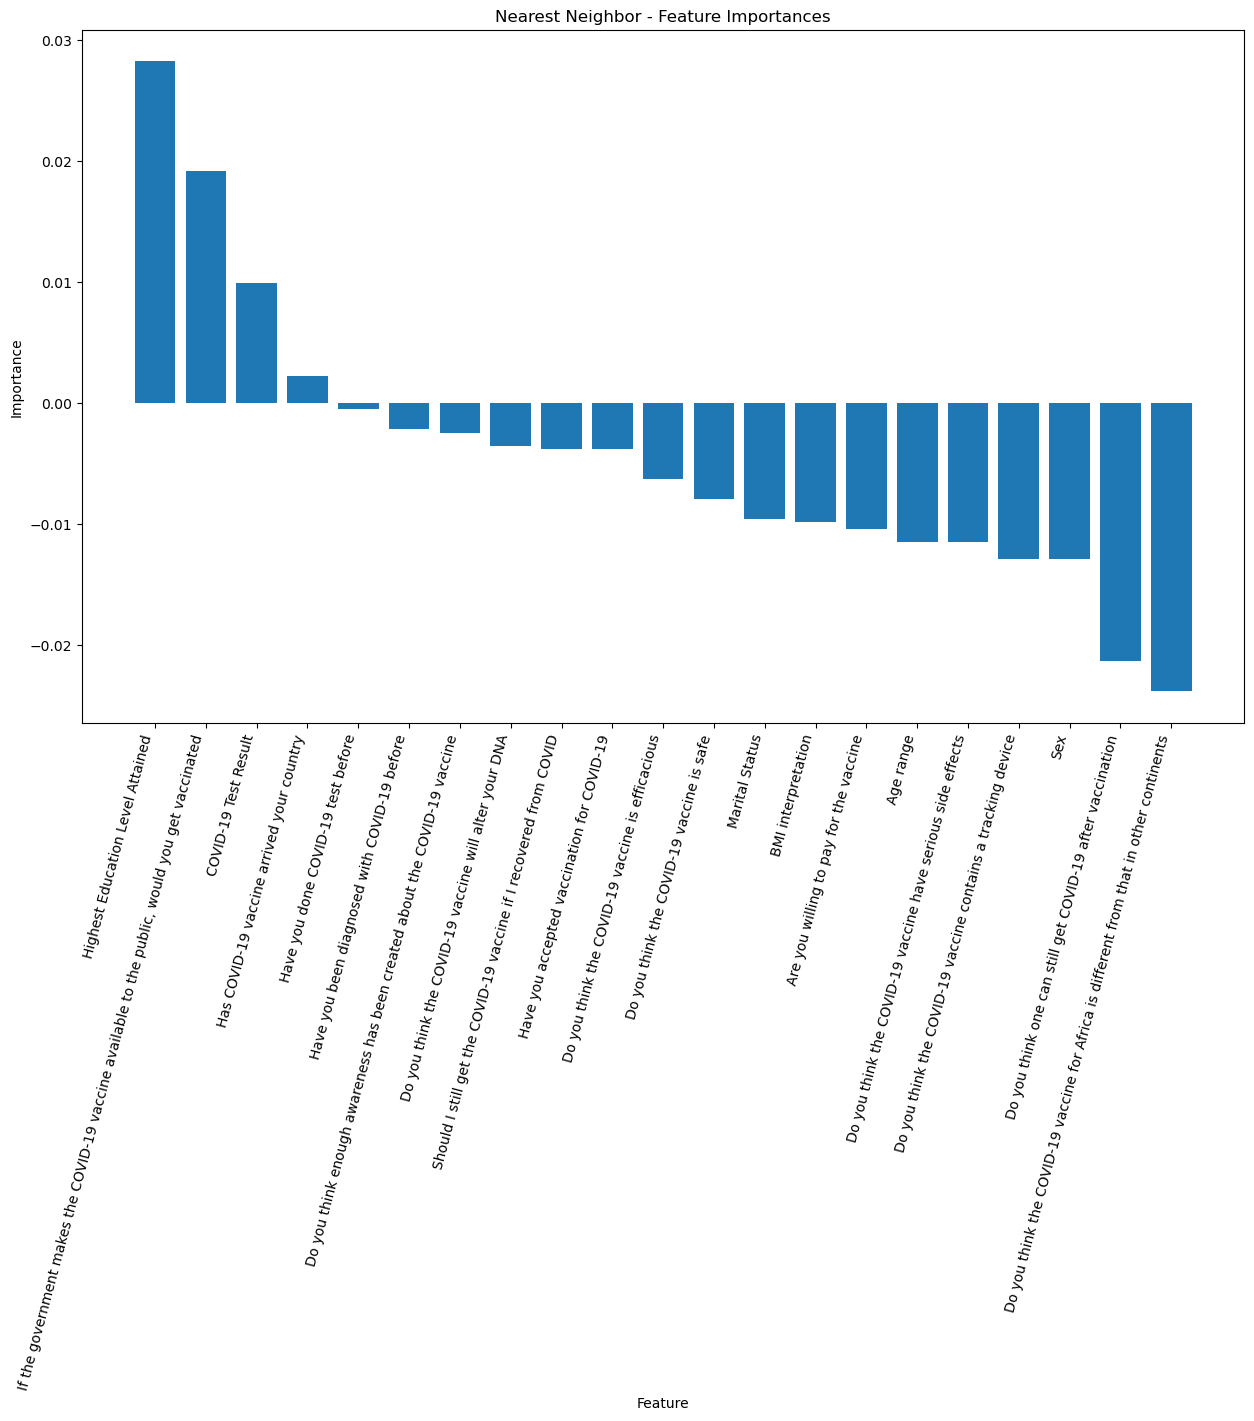

In [12]:
# Plotting feature importances
plt.figure(figsize=(15, 9))  # Adjust the size as needed
plt.bar(importance_knn['Feature'], importance_knn['Importance'])
plt.title("Nearest Neighbor - Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=75, ha="right")  # Rotate x-axis labels for readability
plt.show()  # Display the plot

In [13]:
# Make predictions on the test set
y_pred = knn.predict(x_test)

# 1. Predict Probabilities
y_proba = knn.predict_proba(x_test)[:, 1] # Probabilities for the positive class

# Calculate and print evaluation metrics
accuracy_knn = accuracy_score(y_test, y_pred)
precision_knn = precision_score(y_test, y_pred, average='weighted')
recall_knn = recall_score(y_test, y_pred, average='weighted')
f1_knn = f1_score(y_test, y_pred, average='weighted')
auc_knn = roc_auc_score(y_test, y_proba)

print("K-Nearest Neighbor ")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print(f"ROC AUC: {auc_knn:.4f}")

K-Nearest Neighbor 
Accuracy: 0.5727
Precision: 0.5797
Recall: 0.5727
F1-Score: 0.5751
ROC AUC: 0.5610


| Feature                                                                                        | Importance   |
|:-----------------------------------------------------------------------------------------------|:-------------|
| Marital Status                                                                                 | 0.441343     |
| Age range                                                                                      | 0.330751     |
| Do you think the COVID-19 vaccine will alter your DNA                                          | 0.232243     |
| BMI interpretation                                                                             | 0.11726      |
| Highest Education Level Attained                                                               | 0.116435     |
| Do you think one can still get COVID-19 after vaccination                                      | 0.0737953    |
| Has COVID-19 vaccine arrived your country                                             

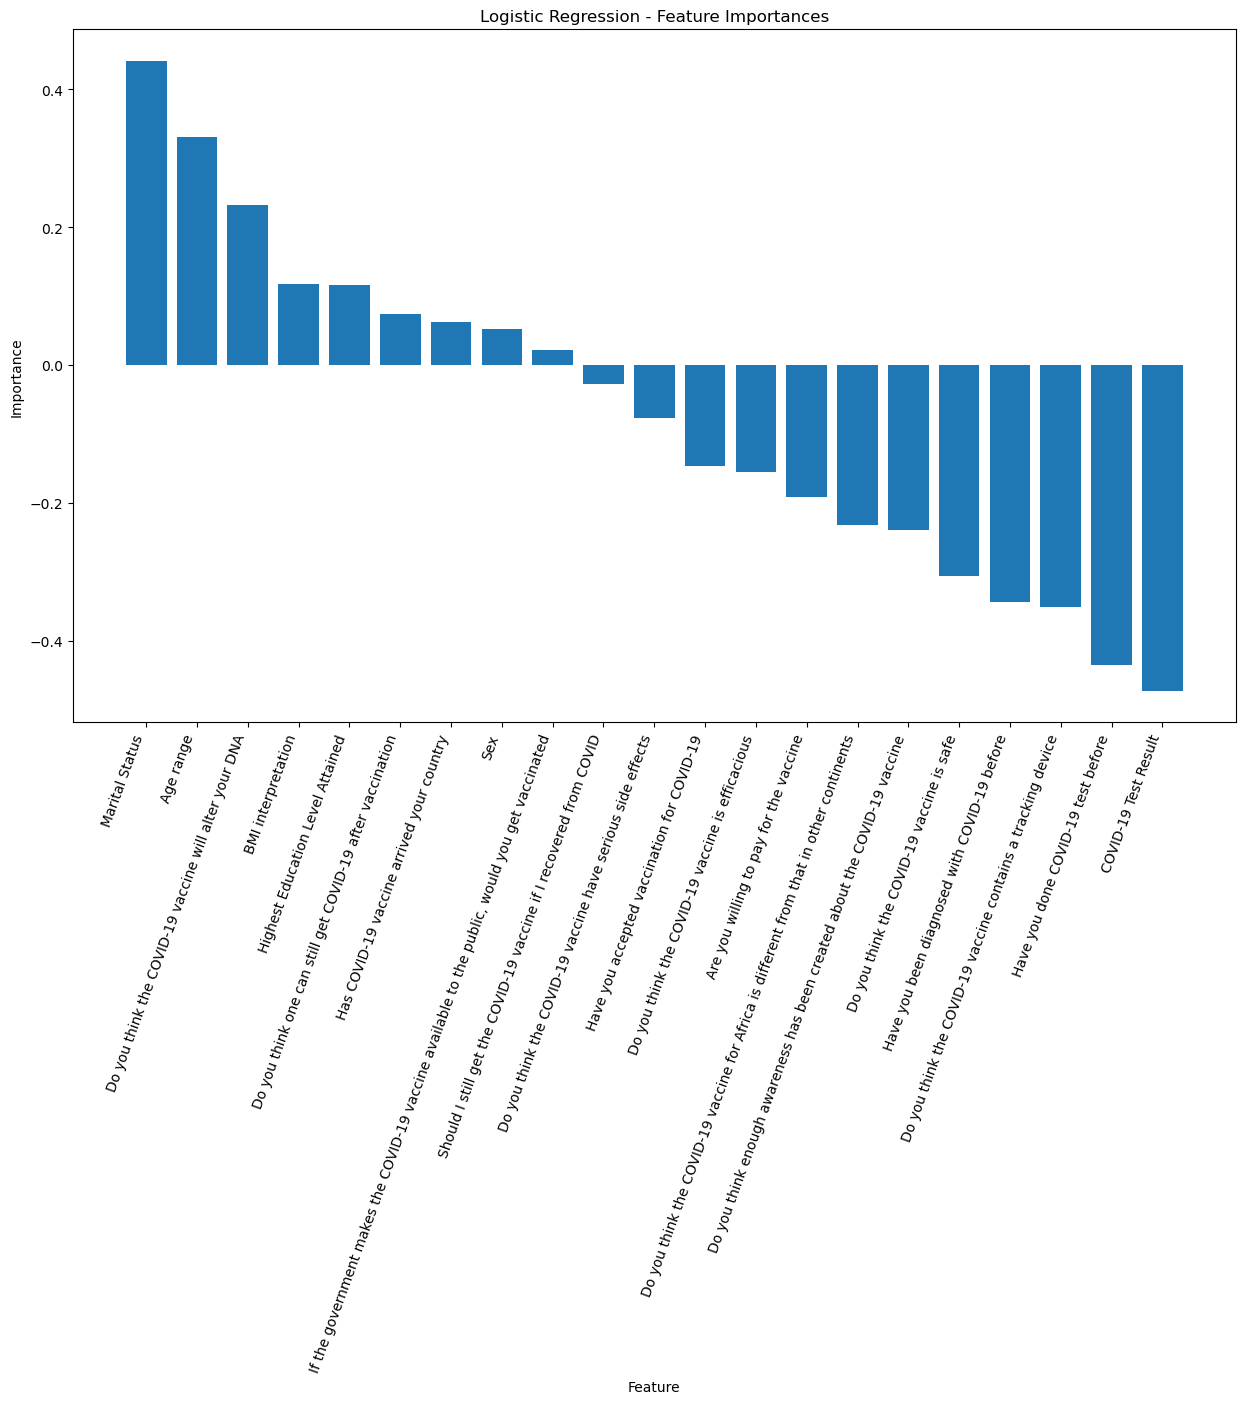

In [14]:
# a. Logistic Regression
LogReg = LogisticRegression(max_iter=1000)
LogReg.fit(x_train, y_train)
importances = LogReg.coef_[0]

importance_lr = pd.DataFrame({'Feature': x.columns, 'Importance': importances})

# Sort by importance and visualize (optional)
importance_lr = importance_lr.sort_values(by='Importance', ascending=False)
print(importance_lr.head(10).to_markdown(index=False, numalign="left", stralign="left"))
imp = importance_lr.head(10).to_markdown(index=False, numalign="left", stralign="left")

# Make predictions on the test set
y_pred = LogReg.predict(x_test)

# 1. Predict Probabilities
y_proba = LogReg.predict_proba(x_test)[:, 1] # Probabilities for the positive class

# Calculate and print evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred, average='weighted')
recall_lr = recall_score(y_test, y_pred, average='weighted')
f1_lr = f1_score(y_test, y_pred, average='weighted')
auc_lr = roc_auc_score(y_test, y_proba)

print("K-Nearest Neighbor ")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"ROC AUC: {auc_lr:.4f}")
# plotting faeture importance 
plt.figure(figsize=(15, 9))  # Adjust the size as needed
plt.bar(importance_lr['Feature'], importance_lr['Importance'])
plt.title('Logistic Regression - Feature Importances')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=70, ha='right')  # Rotate x-axis labels for readability
plt.savefig('logistic_regression_feature_importance.png')
plt.show()  # Display the plot



| Feature                                                                                        | Importance   |
|:-----------------------------------------------------------------------------------------------|:-------------|
| Do you think enough awareness has been created about the COVID-19 vaccine                      | 0.0907714    |
| BMI interpretation                                                                             | 0.0776519    |
| Do you think the COVID-19 vaccine will alter your DNA                                          | 0.0727891    |
| If the government makes the COVID-19 vaccine available to the public, would you get vaccinated | 0.0681942    |
| Highest Education Level Attained                                                               | 0.0638781    |
| Are you willing to pay for the vaccine                                                         | 0.0609143    |
| Age range                                                                             

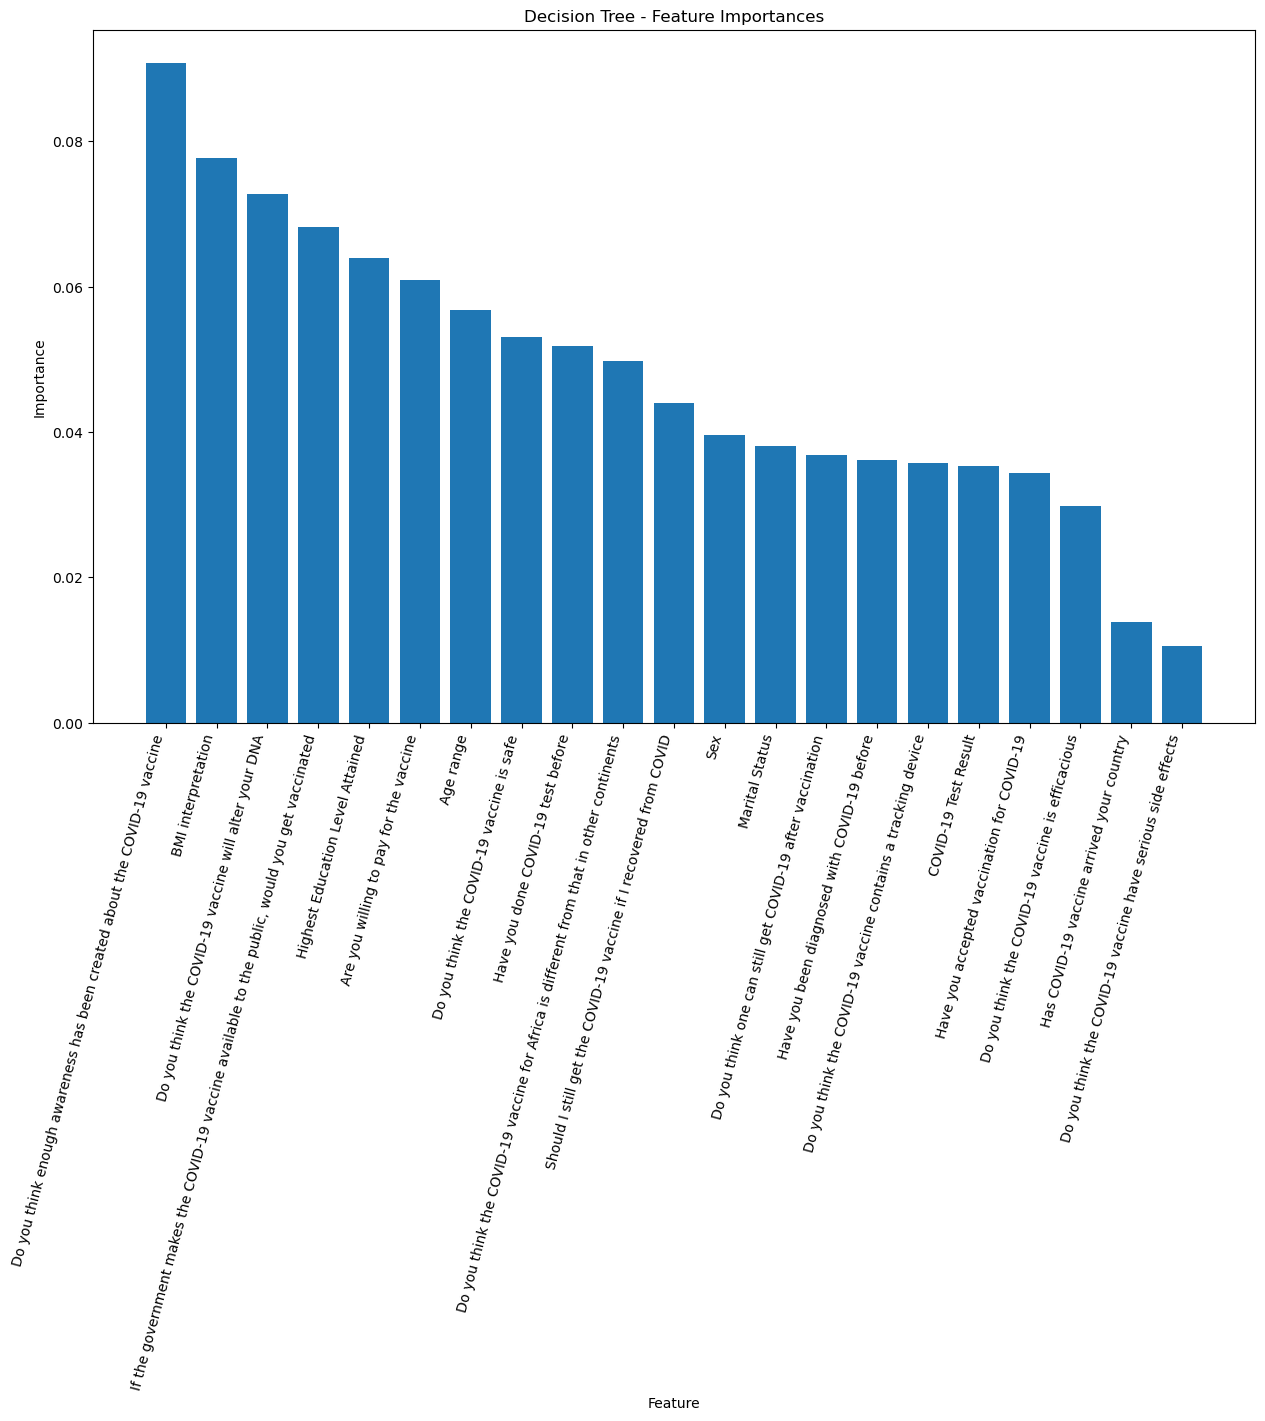

In [15]:
# b. DT Model
Dt_model = DecisionTreeClassifier()

# Training the model
Dt_model.fit(x_train, y_train)

# Extracting the key factors
importance_dt = Dt_model.feature_importances_

# Put the extracted key factors in a table
importance_dt = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance_dt
})

# Sort by importance and visualize (optional)
importance_dt = importance_dt.sort_values(by='Importance', ascending=False)
print(importance_dt.head(10).to_markdown(index=False, numalign='left', stralign='left'))

# Make predictions on the test set
y_pred = Dt_model.predict(x_test)

# 1. Predict Probabilities
y_proba = Dt_model.predict_proba(x_test)[:, 1]  # Probabilities for the positive class

# Calculate and print evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred)
precision_dt = precision_score(y_test, y_pred, average='weighted')
recall_dt = recall_score(y_test, y_pred, average='weighted')
f1_dt = f1_score(y_test, y_pred, average='weighted')
auc_dt = roc_auc_score(y_test, y_proba)

print("Decision Tree")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f'ROC AUC: {auc_dt:.4f}')
# Plotting feature importances
plt.figure(figsize=(15, 9))  # Adjust the size as needed
plt.bar(importance_dt['Feature'], importance_dt['Importance'])
plt.title("Decision Tree - Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=75, ha="right")  # Rotate x-axis labels for readability
plt.show()  # Display the plot

| Feature                                                                                        | Importance   |
|:-----------------------------------------------------------------------------------------------|:-------------|
| If the government makes the COVID-19 vaccine available to the public, would you get vaccinated | 0.0783086    |
| BMI interpretation                                                                             | 0.0776988    |
| Should I still get the COVID-19 vaccine if I recovered from COVID                              | 0.0590812    |
| Do you think the COVID-19 vaccine for Africa is different from that in other continents        | 0.0572219    |
| Do you think the COVID-19 vaccine contains a tracking device                                   | 0.0566711    |
| Do you think one can still get COVID-19 after vaccination                                      | 0.0564817    |
| Do you think the COVID-19 vaccine will alter your DNA                                 

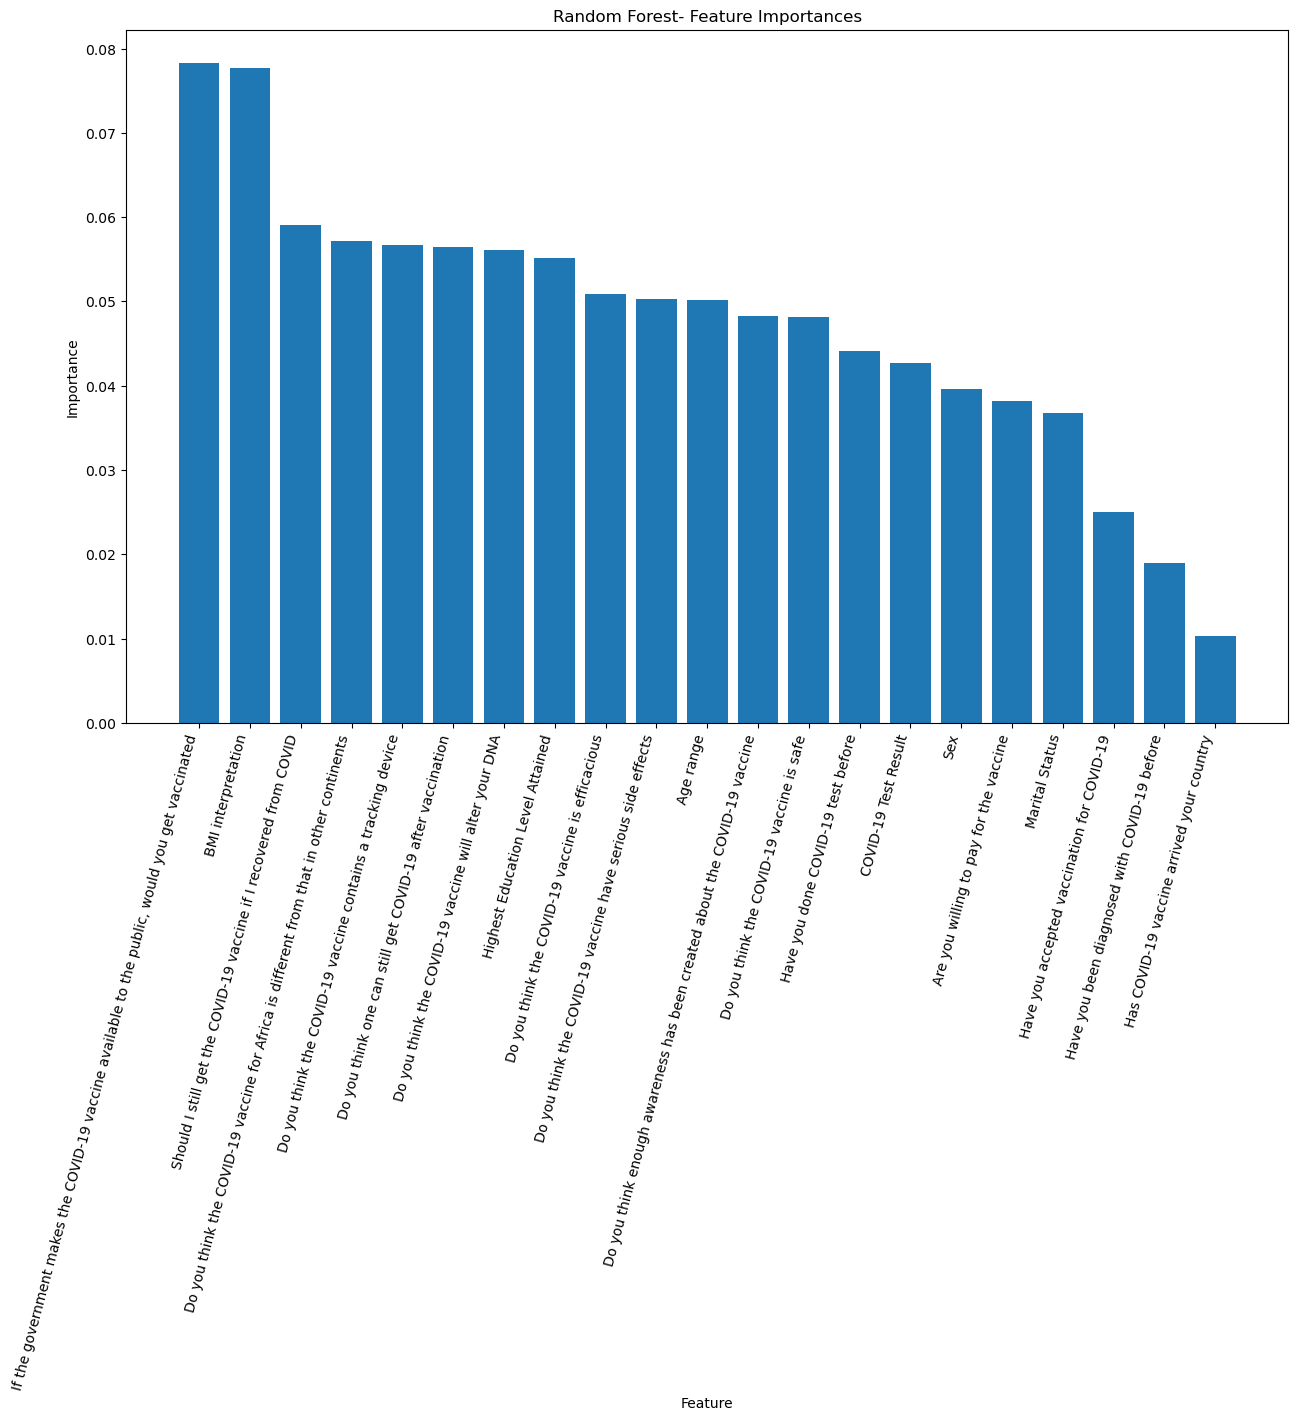

In [16]:
# c. RandomForestClassifier()
Rf_model = RandomForestClassifier()
Rf_model.fit(x_train, y_train)

importance_rf = Rf_model.feature_importances_
importance_rf = pd.DataFrame({'Feature': x.columns, 'Importance': importance_rf})

# Sort by importance and visualize (optional)
importance_rf = importance_rf.sort_values(by='Importance', ascending=False)
print(importance_rf.head(10).to_markdown(index=False, numalign="left", stralign="left"))

# Make predictions on the test set
y_pred = Rf_model.predict(x_test)

# 1. Predict Probabilities
y_proba = Rf_model.predict_proba(x_test)[:, 1] # Probabilities for the positive class

# Calculate and print evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred)
precision_rf = precision_score(y_test, y_pred, average='weighted')
recall_rf = recall_score(y_test, y_pred, average='weighted')
f1_rf = f1_score(y_test, y_pred, average='weighted')
auc_rf = roc_auc_score(y_test, y_proba)

print("Random Forest")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f'ROC AUC: {auc_rf:.4f}')

# Plotting feature importances
plt.figure(figsize=(15,9))  # Adjust the size as needed
plt.bar(importance_rf['Feature'], importance_rf['Importance'])
plt.title("Random Forest- Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=75, ha="right")  # Rotate x-axis labels for readability
plt.show()  # Display the plot

                                              Feature  Importance
20                                 BMI interpretation    0.106354
18  Do you think enough awareness has been created...    0.104842
12  Do you think one can still get COVID-19 after ...    0.067502
15  Should I still get the COVID-19 vaccine if I r...    0.066664
16  If the government makes the COVID-19 vaccine a...    0.066128
11  Do you think the COVID-19 vaccine for Africa i...    0.059179
9   Do you think the COVID-19 vaccine contains a t...    0.055175
3                    Highest Education Level Attained    0.053928
0                                           Age range    0.051423
2                                      Marital Status    0.047736
8   Do you think the COVID-19 vaccine will alter y...    0.047617
14       Have you been diagnosed with COVID-19 before    0.039809
13                 Have you done COVID-19 test before    0.034120
19                               COVID-19 Test Result    0.030459
6         

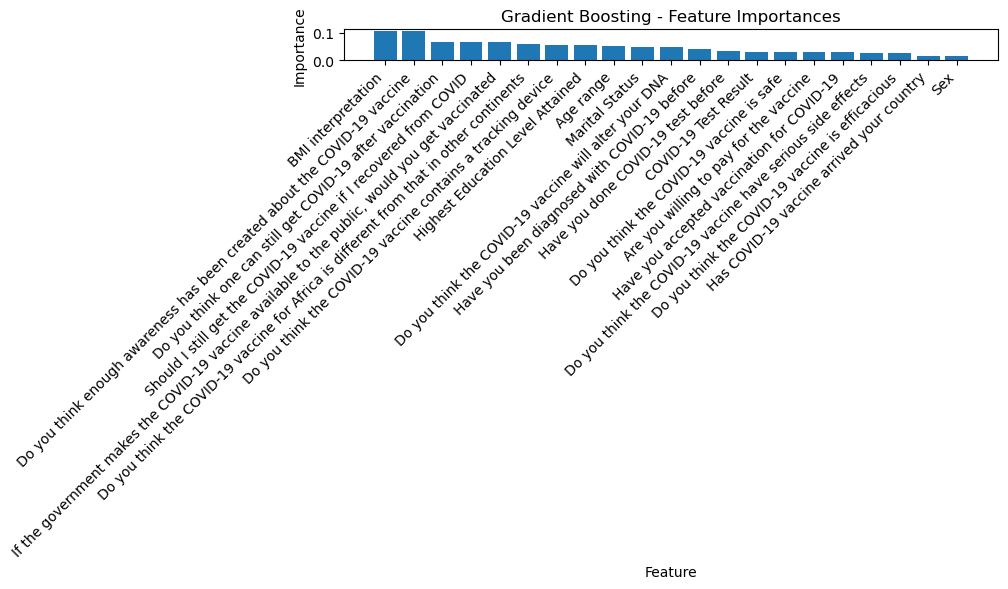

In [17]:
# 3. Build Gradient Boosting model
Gb_model = GradientBoostingClassifier(n_estimators=100, 
                                     learning_rate=0.1, random_state=42)
# You can adjust hyperparameters like n_estimators, learning_rate, max_depth

# 4. Train the model
Gb_model.fit(x_train, y_train)

# 8. Feature importance
importance_gb = Gb_model.feature_importances_

# Create a DataFrame for better visualization and sorting
feature_names = x_train.columns  # Assuming x_train is a pandas DataFrame
importance_Gb = pd.DataFrame({'Feature': feature_names, 'Importance': importance_gb})

# Sort by importance
importance_Gb = importance_Gb.sort_values(by='Importance', ascending=False)

# Print feature importances
print(importance_Gb)


# 5. Get training and testing accuracy
train_accuracy = Gb_model.score(x_train, y_train)
test_accuracy = Gb_model.score(x_test, y_test)

y_proba = Gb_model.predict_proba(x_test)[:, 1] # Probabilities for the positive class

# Calculate and print evaluation metrics
accuracy_Gb = accuracy_score(y_test, y_pred)
precision_Gb = precision_score(y_test, y_pred, average='weighted')
recall_Gb = recall_score(y_test, y_pred, average='weighted')
f1_Gb = f1_score(y_test, y_pred, average='weighted')
auc_Gb = roc_auc_score(y_test, y_proba)

print("Gradient Boosting")
print(f"Accuracy: {accuracy_Gb:.4f}")
print(f"Precision: {precision_Gb:.4f}")
print(f"Recall: {recall_Gb:.4f}")
print(f"F1-Score: {f1_Gb:.4f}")
print(f"ROC AUC: {auc_Gb:.4f}")

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(importance_Gb['Feature'], importance_Gb['Importance'])
plt.title("Gradient Boosting - Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

| Feature                                                                                        | Importance   |
|:-----------------------------------------------------------------------------------------------|:-------------|
| If the government makes the COVID-19 vaccine available to the public, would you get vaccinated | 0.0831373    |
| Highest Education Level Attained                                                               | 0.067451     |
| Should I still get the COVID-19 vaccine if I recovered from COVID                              | 0.0478431    |
| Do you think the COVID-19 vaccine for Africa is different from that in other continents        | 0.0368627    |
| Do you think one can still get COVID-19 after vaccination                                      | 0.0345098    |
| Are you willing to pay for the vaccine                                                         | 0.0290196    |
| Do you think the COVID-19 vaccine have serious side effects                           

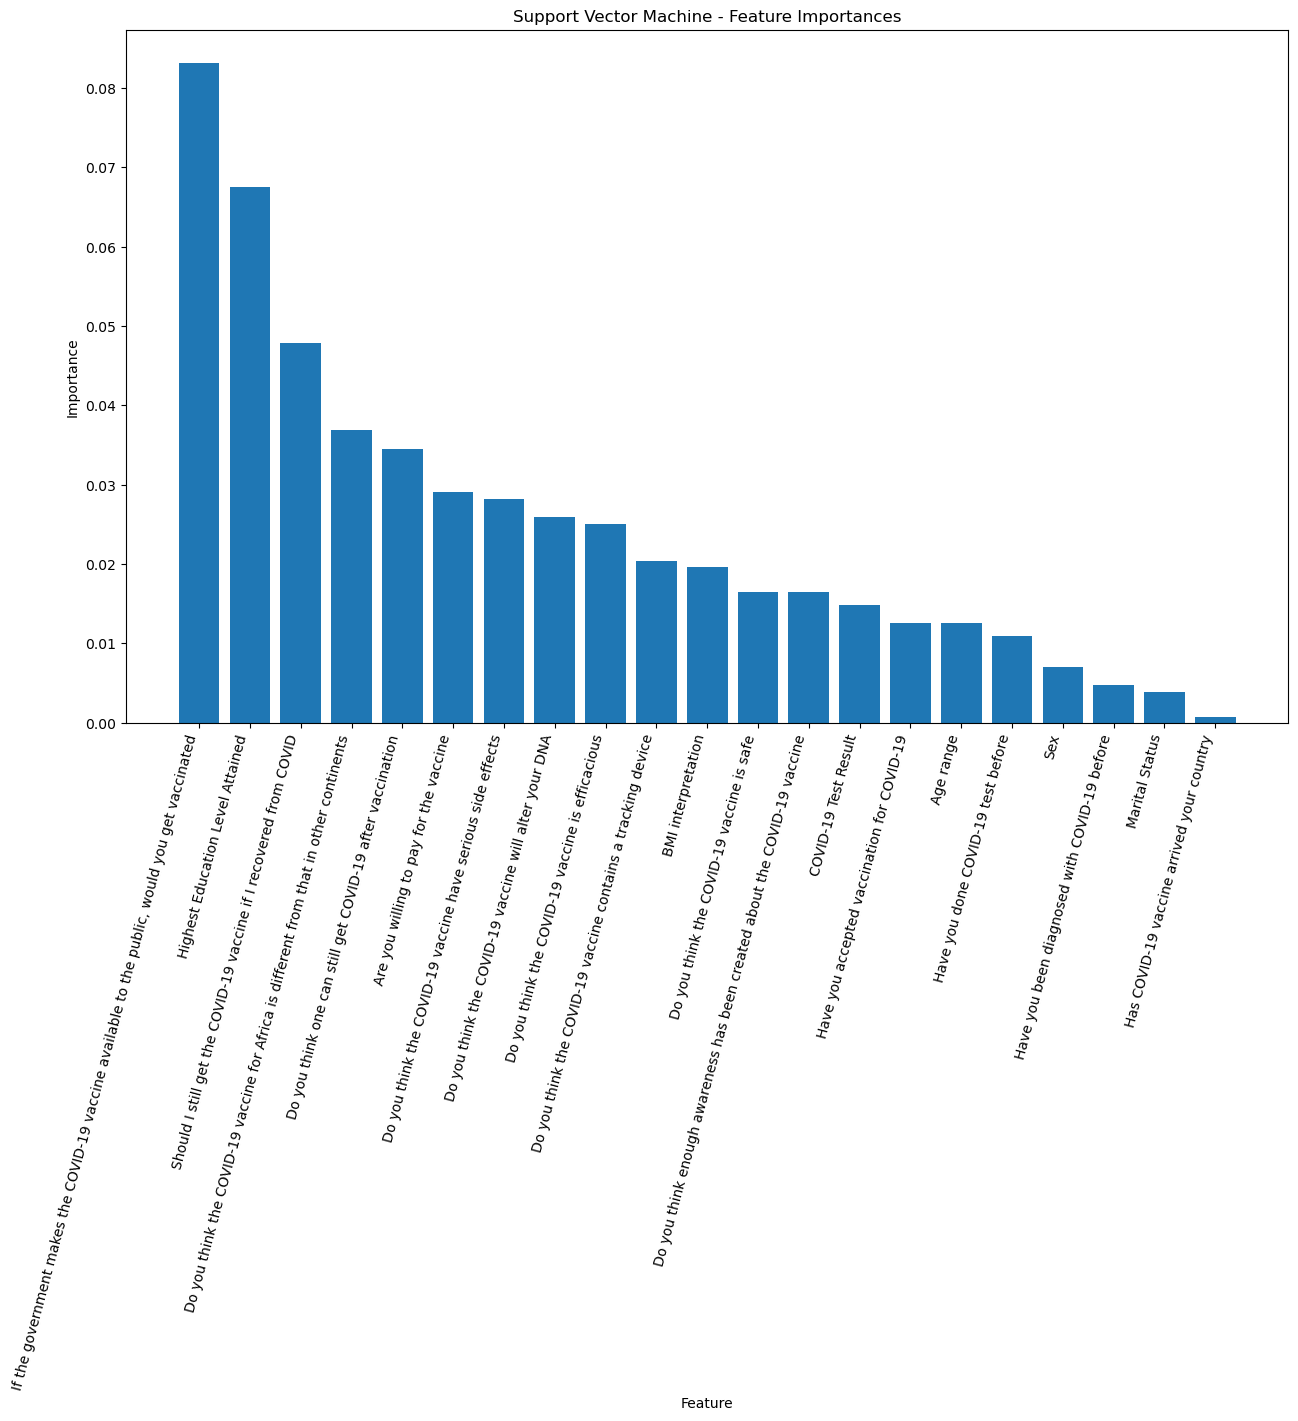

In [18]:
# e. Support Vector Machine (using permutation importance)
Svm_model = SVC(probability=True)
# TRAIN THE model 
Svm_model.fit(x_train, y_train)

# extracting the key factors
sv_result = permutation_importance(Svm_model, x_train, y_train, n_repeats=5, random_state=42)
importance_sv = sv_result.importances_mean
# put extracted key factors in a table 
importance_sv = pd.DataFrame({'Feature': x.columns, 'Importance': importance_sv})

# Sort by importance and visualize (optional)
importance_sv = importance_sv.sort_values(by='Importance', ascending=False)
print(importance_sv.head(10).to_markdown(index=False, numalign="left", stralign="left"))

# Make predictions on the test set
y_pred = Svm_model.predict(x_test)

# 1. Predict Probabilities
y_proba = Svm_model.predict_proba(x_test)[:, 1] # Probabilities for the positive class

# Calculate and print evaluation metrics
accuracy_sv = accuracy_score(y_test, y_pred)
precision_sv = precision_score(y_test, y_pred, average='weighted')
recall_sv = recall_score(y_test, y_pred, average='weighted')
f1_sv = f1_score(y_test, y_pred, average='weighted')
auc_sv = roc_auc_score(y_test, y_proba)

print("Support Vector Machine")
print(f"Accuracy: {accuracy_sv:.4f}")
print(f"Precision: {precision_sv:.4f}")
print(f"Recall: {recall_sv:.4f}")
print(f"F1-Score: {f1_sv:.4f}")
print(f"ROC AUC: {auc_sv:.4f}")

# Plotting feature importances
plt.figure(figsize=(15, 9)) # Adjust the size as needed
plt.bar(importance_sv['Feature'], importance_sv['Importance'])
plt.title("Support Vector Machine - Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=75, ha="right") # Rotate x-axis labels for readability
plt.show() # Display the plot

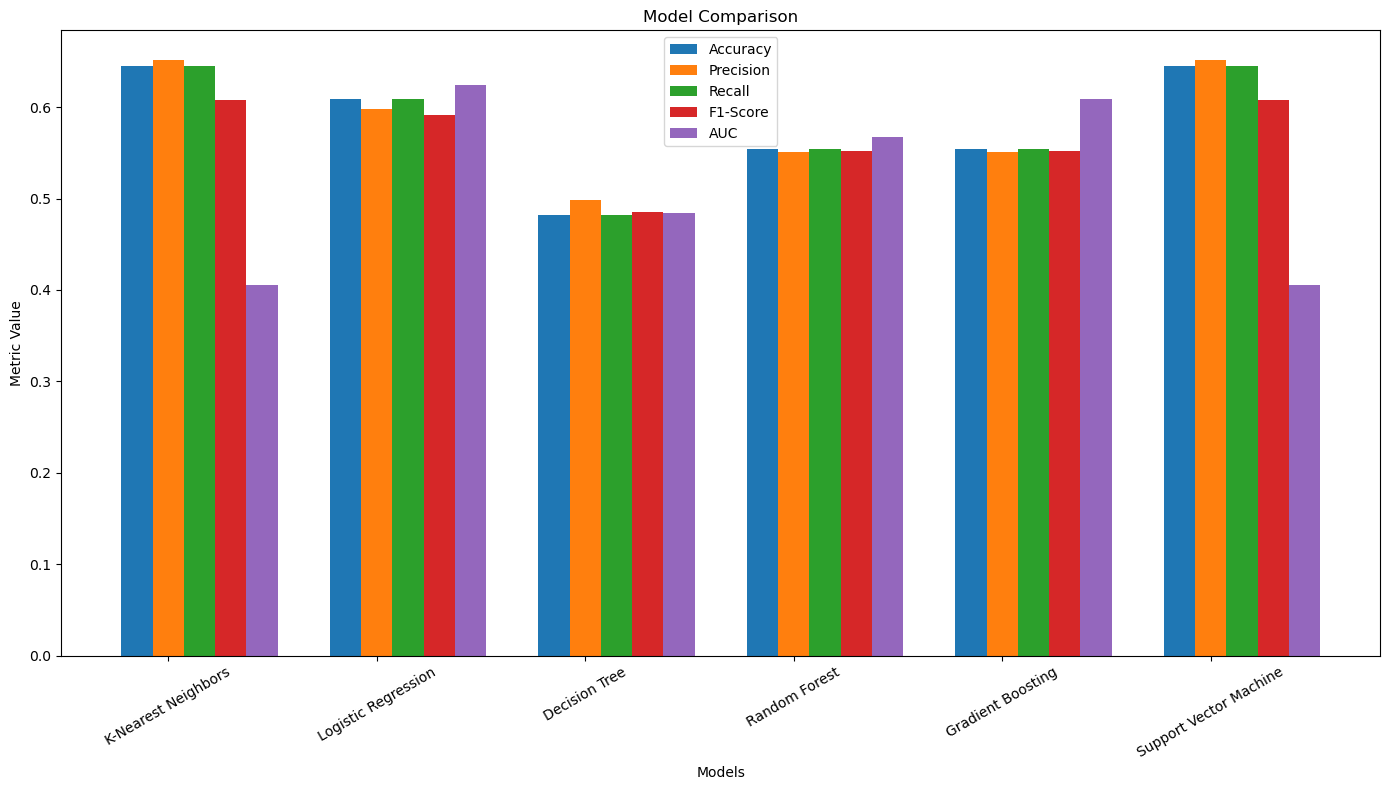

In [19]:
# Plotting the metrics
# Calculate and print evaluation metrics
accuracy_knn = accuracy_score(y_test, y_pred)
precision_knn = precision_score(y_test, y_pred, average='weighted')
recall_knn = recall_score(y_test, y_pred, average='weighted')
f1_knn = f1_score(y_test, y_pred, average='weighted')
auc_knn = roc_auc_score(y_test, y_proba)

accuracies = [accuracy_knn, accuracy_lr, accuracy_dt, accuracy_rf, accuracy_Gb, accuracy_sv]
precisions = [precision_knn, precision_lr, precision_dt, precision_rf, precision_Gb, precision_sv]
recalls = [recall_knn, recall_lr, recall_dt, recall_rf, recall_Gb, recall_sv]
aucs = [auc_knn, auc_lr, auc_dt, auc_rf, auc_Gb, auc_sv]
f1_scores = [f1_knn, f1_lr, f1_dt, f1_rf, f1_Gb, f1_sv]

metrics = [accuracies, precisions, recalls, f1_scores, aucs]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
model_names = ['K-Nearest Neighbors', 'Logistic Regression', 'Decision Tree', 'Random Forest', 
               'Gradient Boosting', 'Support Vector Machine']

num_models = len(model_names)
num_metrics = len(metric_names)

bar_width = 0.15
index = np.arange(num_models)

plt.figure(figsize=(14, 8))

for i in range(num_metrics):
    plt.bar(index + i * bar_width, metrics[i], width=bar_width, label=metric_names[i])

plt.xlabel('Models')
plt.ylabel('Metric Value')
plt.title('Model Comparison')
plt.xticks(index + bar_width, model_names, rotation=30)
plt.legend()

plt.tight_layout()
plt.show()
